# Import Libs and Dataset

In [302]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import f1_score, accuracy_score
import time
import warnings
warnings.filterwarnings('ignore')

In [303]:
df = pd.read_csv('/content/census.csv')
df.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


# Data Exploration

In [304]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45222 non-null  int64  
 1   workclass        45222 non-null  object 
 2   education_level  45222 non-null  object 
 3   education-num    45222 non-null  float64
 4   marital-status   45222 non-null  object 
 5   occupation       45222 non-null  object 
 6   relationship     45222 non-null  object 
 7   race             45222 non-null  object 
 8   sex              45222 non-null  object 
 9   capital-gain     45222 non-null  float64
 10  capital-loss     45222 non-null  float64
 11  hours-per-week   45222 non-null  float64
 12  native-country   45222 non-null  object 
 13  income           45222 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 4.8+ MB


In [305]:
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,1101.430344,88.595418,40.938017
std,13.217870,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [306]:
df['income'].value_counts()

,count
income,
<=50K,34014
>50K,11208




> Number of records



In [307]:
n_rec = df.shape[0]
print(f'Number of records: {n_rec}')

Number of records: 45222




> Number of individuals with income >$50,000



In [308]:
n_greater_50k = df[df['income']=='>50K'].shape[0]
print(f'Number of individuals with income > $50,000: {n_greater_50k}')

Number of individuals with income > $50,000: 11208




> Number of individuals with income <=$50,000



In [309]:
n_most_50k = df[df['income']=='<=50K'].shape[0]
print(f'Number of individuals with income <= $50,000: {n_most_50k}')

Number of individuals with income <= $50,000: 34014




> Percentage of individuals with income > $50,000



In [310]:
per_greater_50k = (n_greater_50k / n_rec)*100
print(f'Percentage of individuals with income > $50,000: {per_greater_50k:.2f}%')

Percentage of individuals with income > $50,000: 24.78%


# Data Preprocessing



> Split Data , Target -> then split numerical , categorical




In [311]:
# split into features , traget
income = df['income']
features = df.drop('income', axis=1)

In [312]:
num_col = features.select_dtypes(include=np.number).columns
cat_col = features.select_dtypes(include=['object']).columns

In [313]:
print("Numerical columns:", num_col)
print("Categorical columns:", cat_col)

Numerical columns: Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Categorical columns: Index(['workclass', 'education_level', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')




> check Skewness



In [314]:
features[num_col].skew().sort_values(ascending=False)

,0
capital-gain,11.789002
capital-loss,4.516304
age,0.532816
hours-per-week,0.340545
education-num,-0.310621


💥 should transform capital-gain , capital-loss

In [315]:
# Log-transform the skewed features
skewed = ['capital-gain', 'capital-loss']
features[skewed] = features[skewed].apply(lambda x: np.log(x + 1))

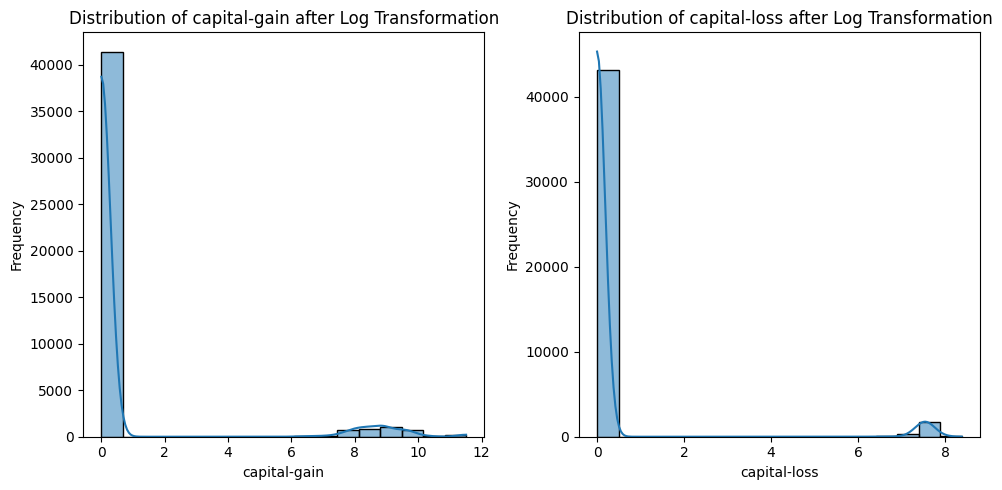

In [316]:
# visualize after transformed
plt.figure(figsize=(10, 5))
for i, col in enumerate(skewed, 1):
    plt.subplot(1, 2, i)
    sns.histplot(features[col], kde=True)
    plt.title(f'Distribution of {col} after Log Transformation')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


> one-hot encoding for feature & income data.

In [317]:
# One-hot encode the features
features = pd.get_dummies(features)

In [318]:
# Encode the income data
income = income.map({'<=50K': 0, '>50K': 1})

In [319]:
print("Features after encoding:", features.shape)
print("Income values:", income.unique())

Features after encoding: (45222, 103)
Income values: [0 1]




> Scaling



In [320]:
# Scale numerical features
scaler = StandardScaler()

# including the log-transformed ones
num_col_to_scale = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
features[num_col_to_scale] = scaler.fit_transform(features[num_col_to_scale])

# Verify scaling worked
print("Numerical columns after scaling:")
print(features[num_col_to_scale].describe())

Numerical columns after scaling:
                age  education-num  capital-gain  capital-loss  hours-per-week
count  4.522200e+04   4.522200e+04  4.522200e+04  4.522200e+04    4.522200e+04
mean  -2.325424e-17   1.655293e-16 -6.520615e-17  4.933670e-17    2.144732e-16
std    1.000011e+00   1.000011e+00  1.000011e+00  1.000011e+00    1.000011e+00
min   -1.630231e+00  -3.571870e+00 -3.003281e-01 -2.227519e-01   -3.326124e+00
25%   -7.980149e-01  -4.381216e-01 -3.003281e-01 -2.227519e-01   -7.812006e-02
50%   -1.171110e-01  -4.640300e-02 -3.003281e-01 -2.227519e-01   -7.812006e-02
75%    6.394489e-01   1.128753e+00 -3.003281e-01 -2.227519e-01    3.382907e-01
max    3.892656e+00   2.303909e+00  4.367390e+00  5.027928e+00    4.835527e+00


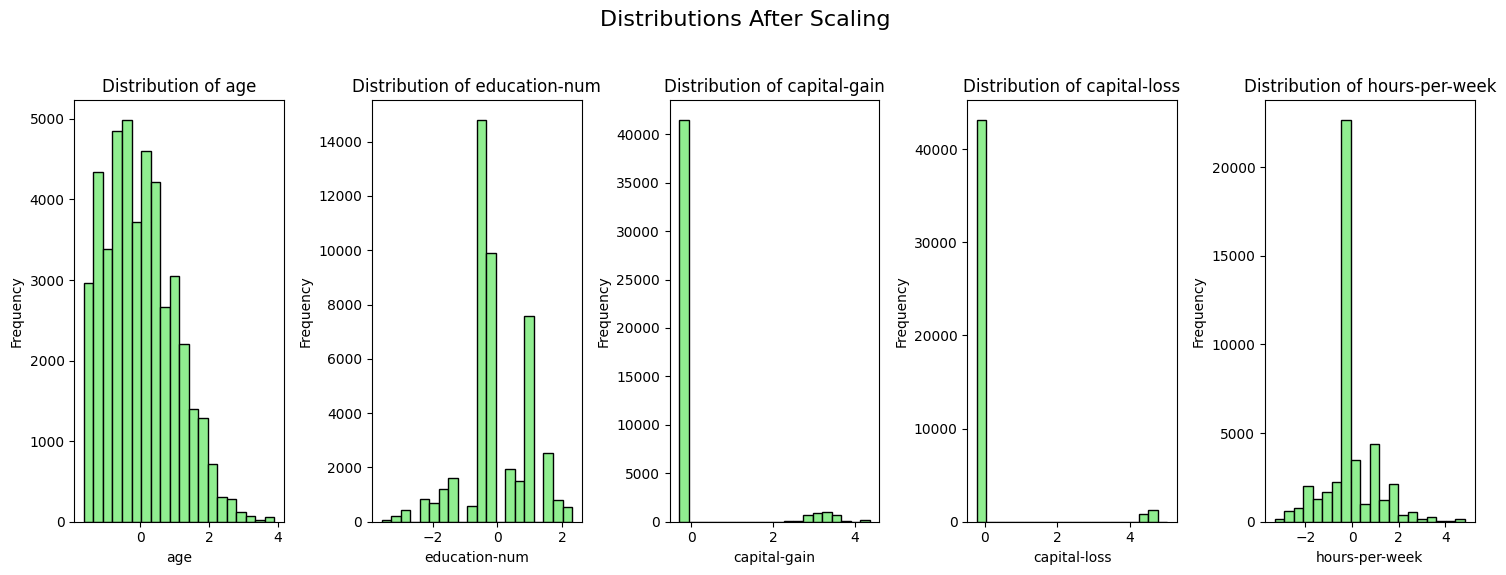

In [321]:
# Visualize distributions after scaling
plt.figure(figsize=(15, 6))
for i, col_name in enumerate(num_col_to_scale):
    plt.subplot(1, len(num_col_to_scale), i + 1)
    plt.hist(features[col_name], bins=20, color='lightgreen', edgecolor='black')
    plt.title(f'Distribution of {col_name}')
    plt.xlabel(col_name)
    plt.ylabel('Frequency')

plt.suptitle('Distributions After Scaling', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



> train & test splitting



In [322]:
x_train, x_test, y_train, y_test = train_test_split(features, income, test_size=0.2, random_state=42)

# Q1 : Naive Predictor Performance

In [323]:
# always predict 1 (majority class)
naive_pred = np.ones_like(income)

# Accuracy
accuracy = accuracy_score(income, naive_pred)

# F1 score
f1 = f1_score(income, naive_pred)

print("Naive Predictor Accuracy:", accuracy)
print("Naive Predictor F1 Score:", f1)

Naive Predictor Accuracy: 0.2478439697492371
Naive Predictor F1 Score: 0.3972355130249867


# Q2





> 1.Model Application

i will use :

*   Logistic Regression
*   Random Forest Classifier

*   XGBoost Classifier

> ▶ for more info see the presentation -_-

> Creating a Training and Predicting Pipeline





In [324]:
# pipeline for each model
pipelines = {
    "Logistic Regression Pipeline": Pipeline([
        ('log_clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest Pipeline": Pipeline([
        ('rf_clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    "XGBoost Pipeline": Pipeline([
        ('xgb_clf', XGBClassifier(n_estimators=100, random_state=42))
    ])
}

In [325]:
# Train, predict, and evaluate for each model
res = {}
for name, pipeline in pipelines.items():
    print(f'$ {name} Started \n')

    start_time = time.time()

    print(f"Training {name}...")
    pipeline.fit(x_train, y_train)

    end_time = time.time()
    training_time = end_time - start_time

    print(f"Predicting {name}...")
    y_pred = pipeline.predict(x_test)

    print(f"Evaluating {name}...")
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    res[name] = {"Accuracy": accuracy, "F1 Score": f1, "Training Time": training_time}

    print(f'{name} Finished \n')
    print('-'*15)

$ Logistic Regression Pipeline Started 

Training Logistic Regression Pipeline...
Predicting Logistic Regression Pipeline...
Evaluating Logistic Regression Pipeline...
Logistic Regression Pipeline Finished 

---------------
$ Random Forest Pipeline Started 

Training Random Forest Pipeline...
Predicting Random Forest Pipeline...
Evaluating Random Forest Pipeline...
Random Forest Pipeline Finished 

---------------
$ XGBoost Pipeline Started 

Training XGBoost Pipeline...
Predicting XGBoost Pipeline...
Evaluating XGBoost Pipeline...
XGBoost Pipeline Finished 

---------------




> Model Evaluation ✴



In [326]:
# Display results
results_df = pd.DataFrame(res).T
print(results_df)

                              Accuracy  F1 Score  Training Time
Logistic Regression Pipeline  0.845108  0.660528       1.366812
Random Forest Pipeline        0.843339  0.672824       6.286180
XGBoost Pipeline              0.871752  0.723018       0.829329


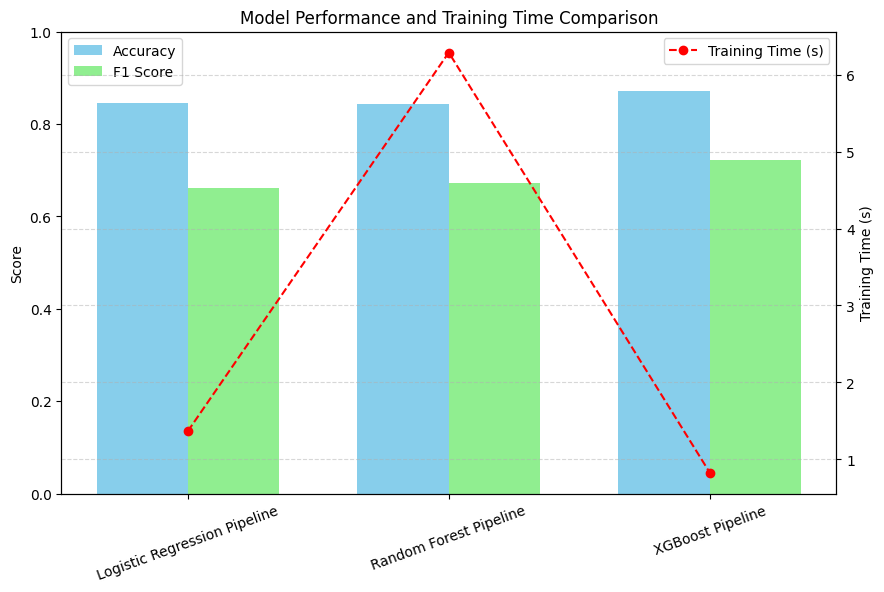

In [327]:
# Visualize the results of the models
fig, ax1 = plt.subplots(figsize=(10,6))
x = np.arange(len(results_df))
width = 0.35

# Bars for Accuracy & F1
ax1.bar([i - width/2 for i in x], results_df['Accuracy'], width=width, label='Accuracy', color='skyblue')
ax1.bar([i + width/2 for i in x], results_df['F1 Score'], width=width, label='F1 Score', color='lightgreen')
ax1.set_ylabel('Score')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df.index, rotation=20)
ax1.set_ylim(0,1)
ax1.legend(loc='upper left')

# Line for Training Time
ax2 = ax1.twinx()
ax2.plot(x, results_df['Training Time'], color='red', marker='o', linestyle='--', label='Training Time (s)')
ax2.set_ylabel('Training Time (s)')
ax2.legend(loc='upper right')

plt.title('Model Performance and Training Time Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Q3 : Choosing the Best Model

In [328]:
# Automatically choose the best model
best_model_name = results_df['F1 Score'].idxmax()   # highest F1
best_model_f1 = results_df['F1 Score'].max()
best_model_accuracy = results_df.loc[best_model_name, 'Accuracy']
best_model_time = results_df.loc[best_model_name, 'Training Time']

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {best_model_accuracy:.3f}")
print(f"F1 Score: {best_model_f1:.3f}")
print(f"Training Time: {best_model_time:.3f} seconds")

Best Model: XGBoost Pipeline
Accuracy: 0.872
F1 Score: 0.723
Training Time: 0.829 seconds


Considering **model performance, computational efficiency, and dataset characteristics**, XGBoost is the best model for the CharityML project:

- It achieves the **highest F1 Score (0.723)**, ensuring donors are correctly identified.

- It trains faster than both Random Forest and Logistic Regression, making it efficient for large datasets.